# Explore Data
## Daten analysieren

Diese Analyse untersucht die California Housing-Daten und bereitet sie für spätere Modellierungs- und Evaluationsschritte auf.

# 1. Setup & Imports
In dieser Sektion werden alle notwendigen Bibliotheken geladen und Warnungen reduziert, damit das Notebook sauber und konsistent läuft.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import fetch_california_housing

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 2. Daten laden
Die California-Housing-Daten werden geladen und anschließend für die explorative Analyse vorbereitet.

In [ ]:
def plot_res(
    data_x,
    data_y,
    weights=None,
    regressor=None,
    is_list=False,
    labels=None,
    is_data_list=False,
    data_labels=None,
    func=None,
    data_style=None,
):
    """
    Plot data points and optionally one or more fitted lines.

    Parameters
    ----------
    data_x : array-like or list of array-like
        X-values for data points. If `is_data_list` is True, this should be a list
        where each element corresponds to one dataset.
    data_y : array-like or list of array-like
        Y-values for data points, matching the structure of `data_x`.
    weights : tuple/list or list of tuples/lists, optional
        Linear model parameters. For a single model: (bias, slope).
        For multiple models (when `is_list` is True): list of (bias, slope) pairs.
    regressor : object, optional
        Model with a `.predict(X)` method (e.g. sklearn regressor). Plotted as a line.
        Expects `predict` to accept shape (n, 1). If it accepts 1D, we fall back.
    is_list : bool, default False
        Whether `weights` contains multiple (bias, slope) pairs.
    labels : list of str, optional
        Labels for the fitted lines. Automatically generated if not provided.
    is_data_list : bool, default False
        Whether `data_x` and `data_y` contain multiple datasets.
    data_labels : list of str, optional
        Labels for the datasets. Automatically generated if not provided.
    func : callable or list of callables, optional
        Transformation applied to x-values before using the weights. For multiple
        models, should be a list of callables. Defaults to identity.
    data_style : list[list[int|float,int|float]] or list[int|float,int|float], optional
        Styling for data points as [markersize, lw].
        Defaults to [[10, 0]] (points only, no connecting line).
    """
    xval = np.arange(0.0, 1.0, 0.01)

    markers = ["o", "v", "s", "D", "X"]
    fig = plt.figure(figsize=(12, 6), dpi=200)
    ax = plt.subplot(111)

    if data_labels is None:
        if is_data_list:
            data_labels = [f"data {i}" for i in range(1, len(data_x) + 1)]
        else:
            data_labels = ["data"]

    if data_style is None:
        data_style = [[10, 0] for _ in range(len(data_x) if is_data_list else 1)]

    if is_data_list:
        for i in range(len(data_x)):
            ms, lw = data_style[i]
            ax.plot(
                data_x[i],
                data_y[i],
                label=data_labels[i],
                lw=lw,
                marker=markers[0],
                markersize=ms,
            )
    else:
        ms, lw = data_style[0]
        ax.plot(
            data_x,
            data_y,
            label=data_labels[0],
            lw=lw,
            marker=markers[0],
            markersize=ms,
        )

    if labels is None:
        if is_list:
            labels = [str(i) for i in range(1, len(weights) + 1)]
        else:
            labels = ["1"]

    if func is None:
        if is_list:
            func = [lambda x: x for _ in range(len(weights))]
        else:
            func = lambda x: x

    if weights is not None:
        if is_list:
            for i, w in enumerate(weights):
                ax.plot(
                    xval,
                    [w[1] * func[i](x) + w[0] for x in xval],
                    label=labels[i],
                    lw=3,
                )
        else:
            ax.plot(
                xval,
                [weights[1] * func(x) + weights[0] for x in xval],
                label=labels[0],
                lw=3,
            )

    if regressor is not None:
        try:
            yhat = regressor.predict(xval.reshape(-1, 1))
        except Exception:
            yhat = regressor.predict(xval)

        reg_label = labels[0] if labels is not None and len(labels) > 0 else "regressor"
        ax.plot(xval, yhat, label=reg_label, lw=3)

    ax.legend(loc="upper left", fancybox=True, fontsize=20)
    plt.xlabel("X", fontsize=20)
    plt.ylabel("Y", fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True)

    all_y = np.hstack(data_y) if is_data_list else np.asarray(data_y)
    all_x = np.hstack(data_x) if is_data_list else np.asarray(data_x)
    plt.ylim(0.9 * all_y.min(), 1.1 * all_y.max())
    plt.xlim(0.9 * all_x.min(), 1.1 * all_x.max())

In [ ]:
housing_data = fetch_california_housing()

## 3. Explorative Datenanalyse
Die einzelnen Merkmale werden visualisiert, um erste Muster und mögliche Ausreißer zu erkennen.

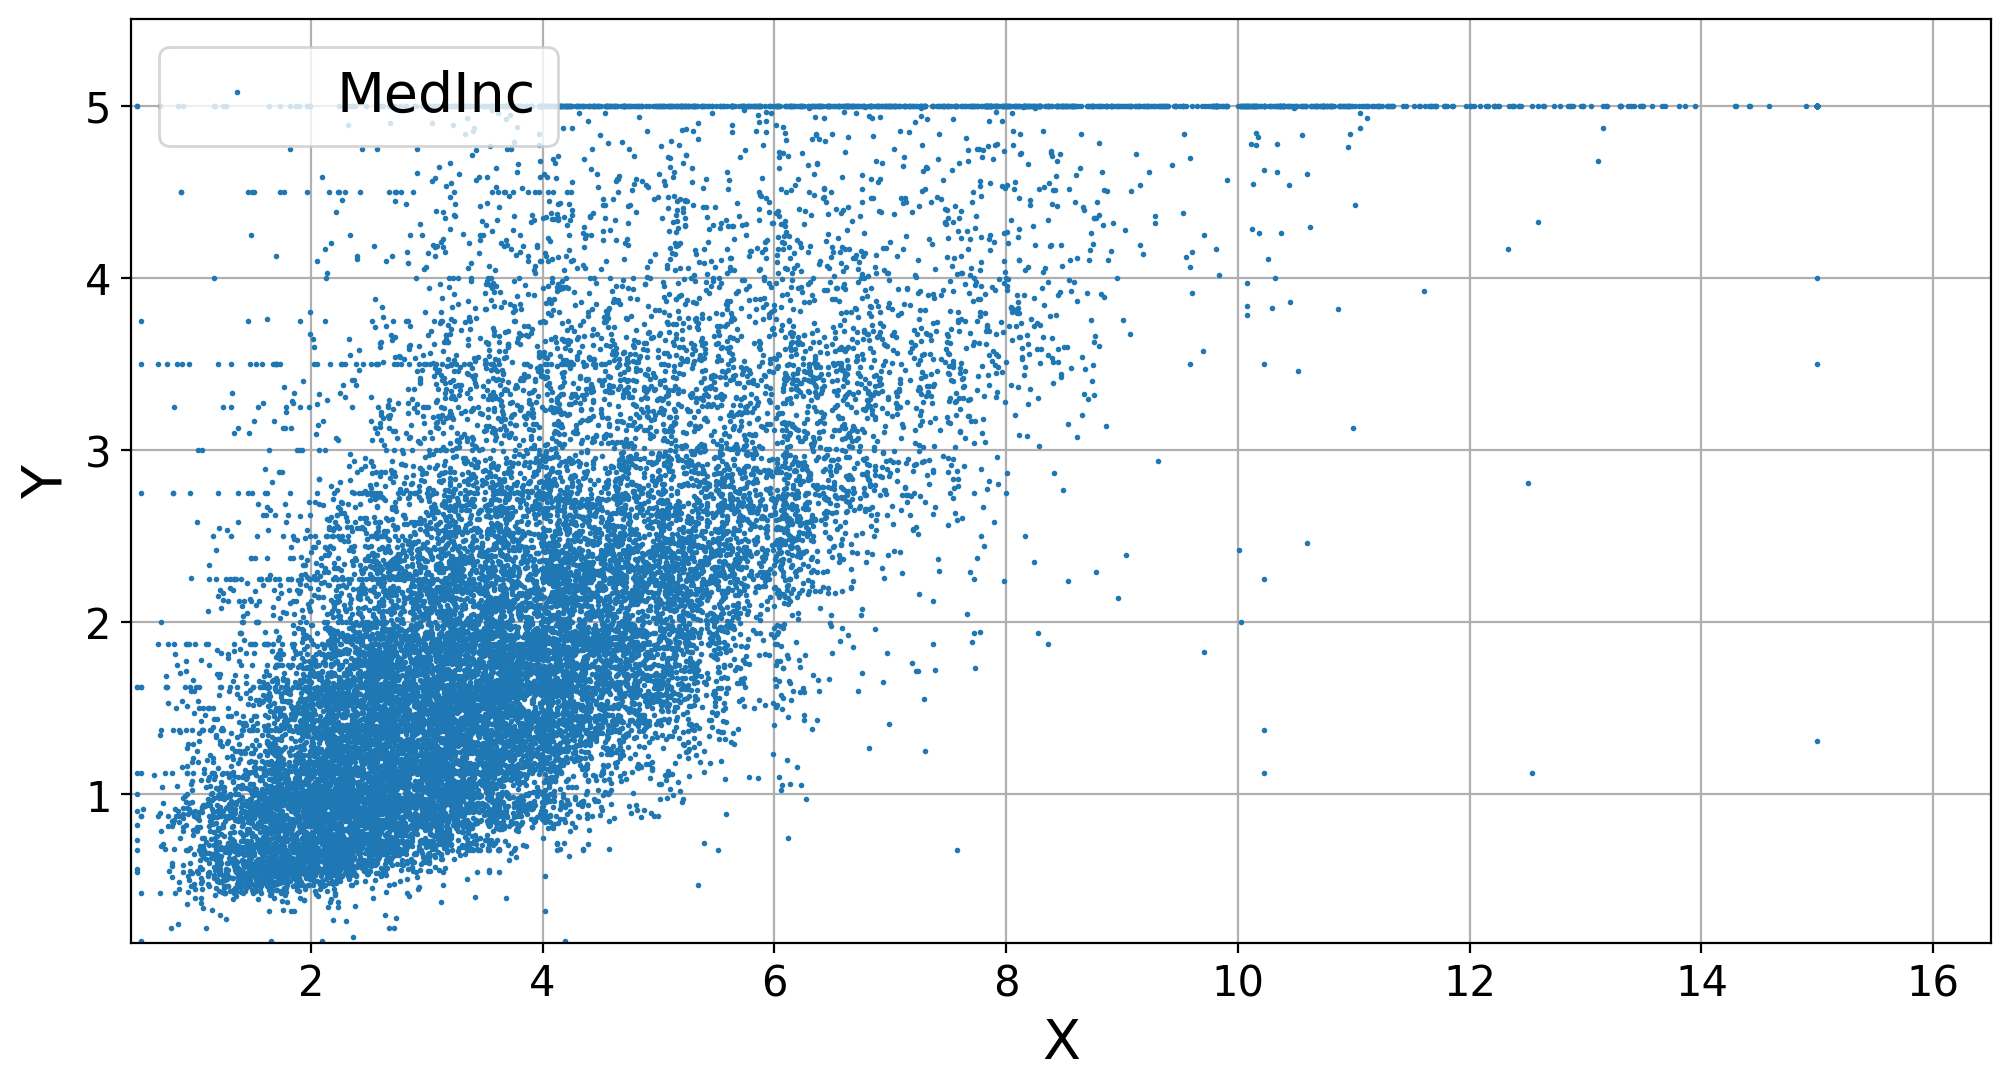

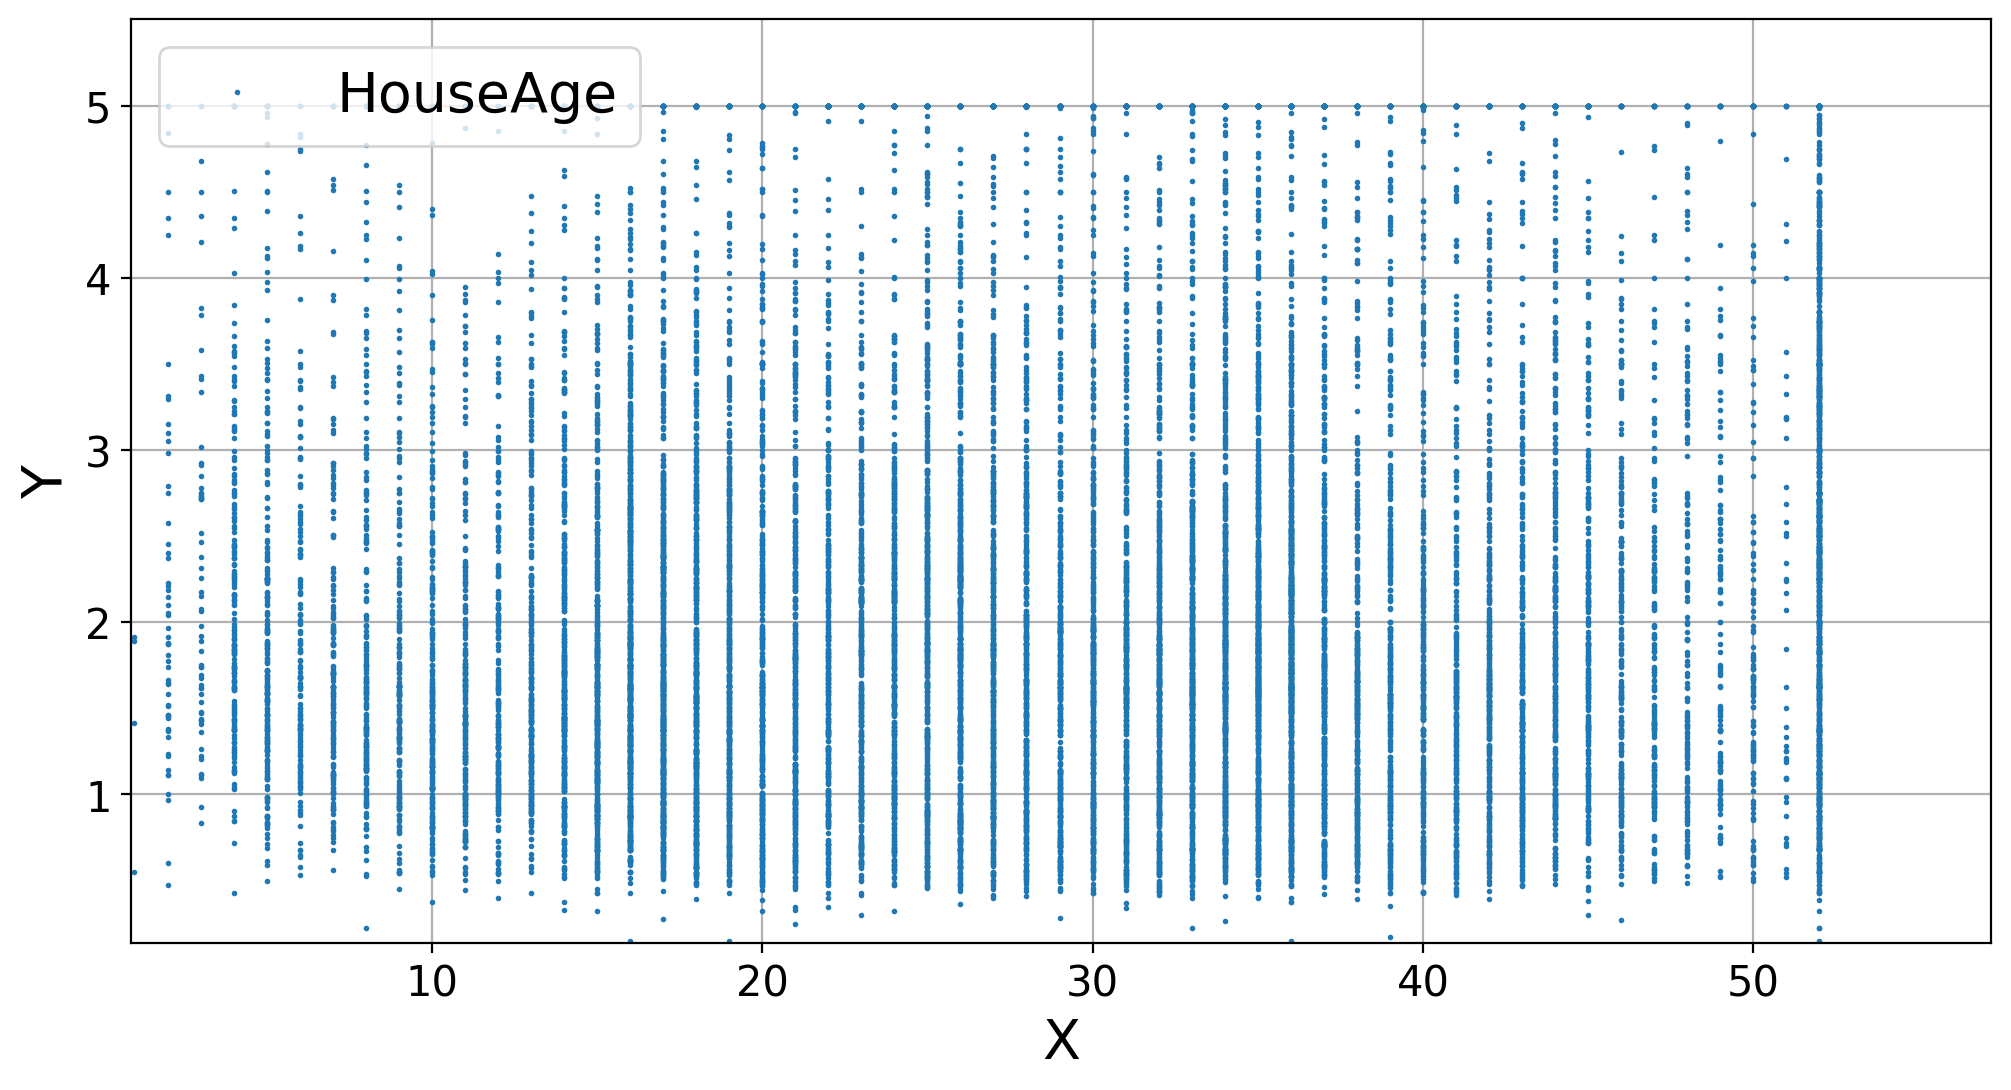

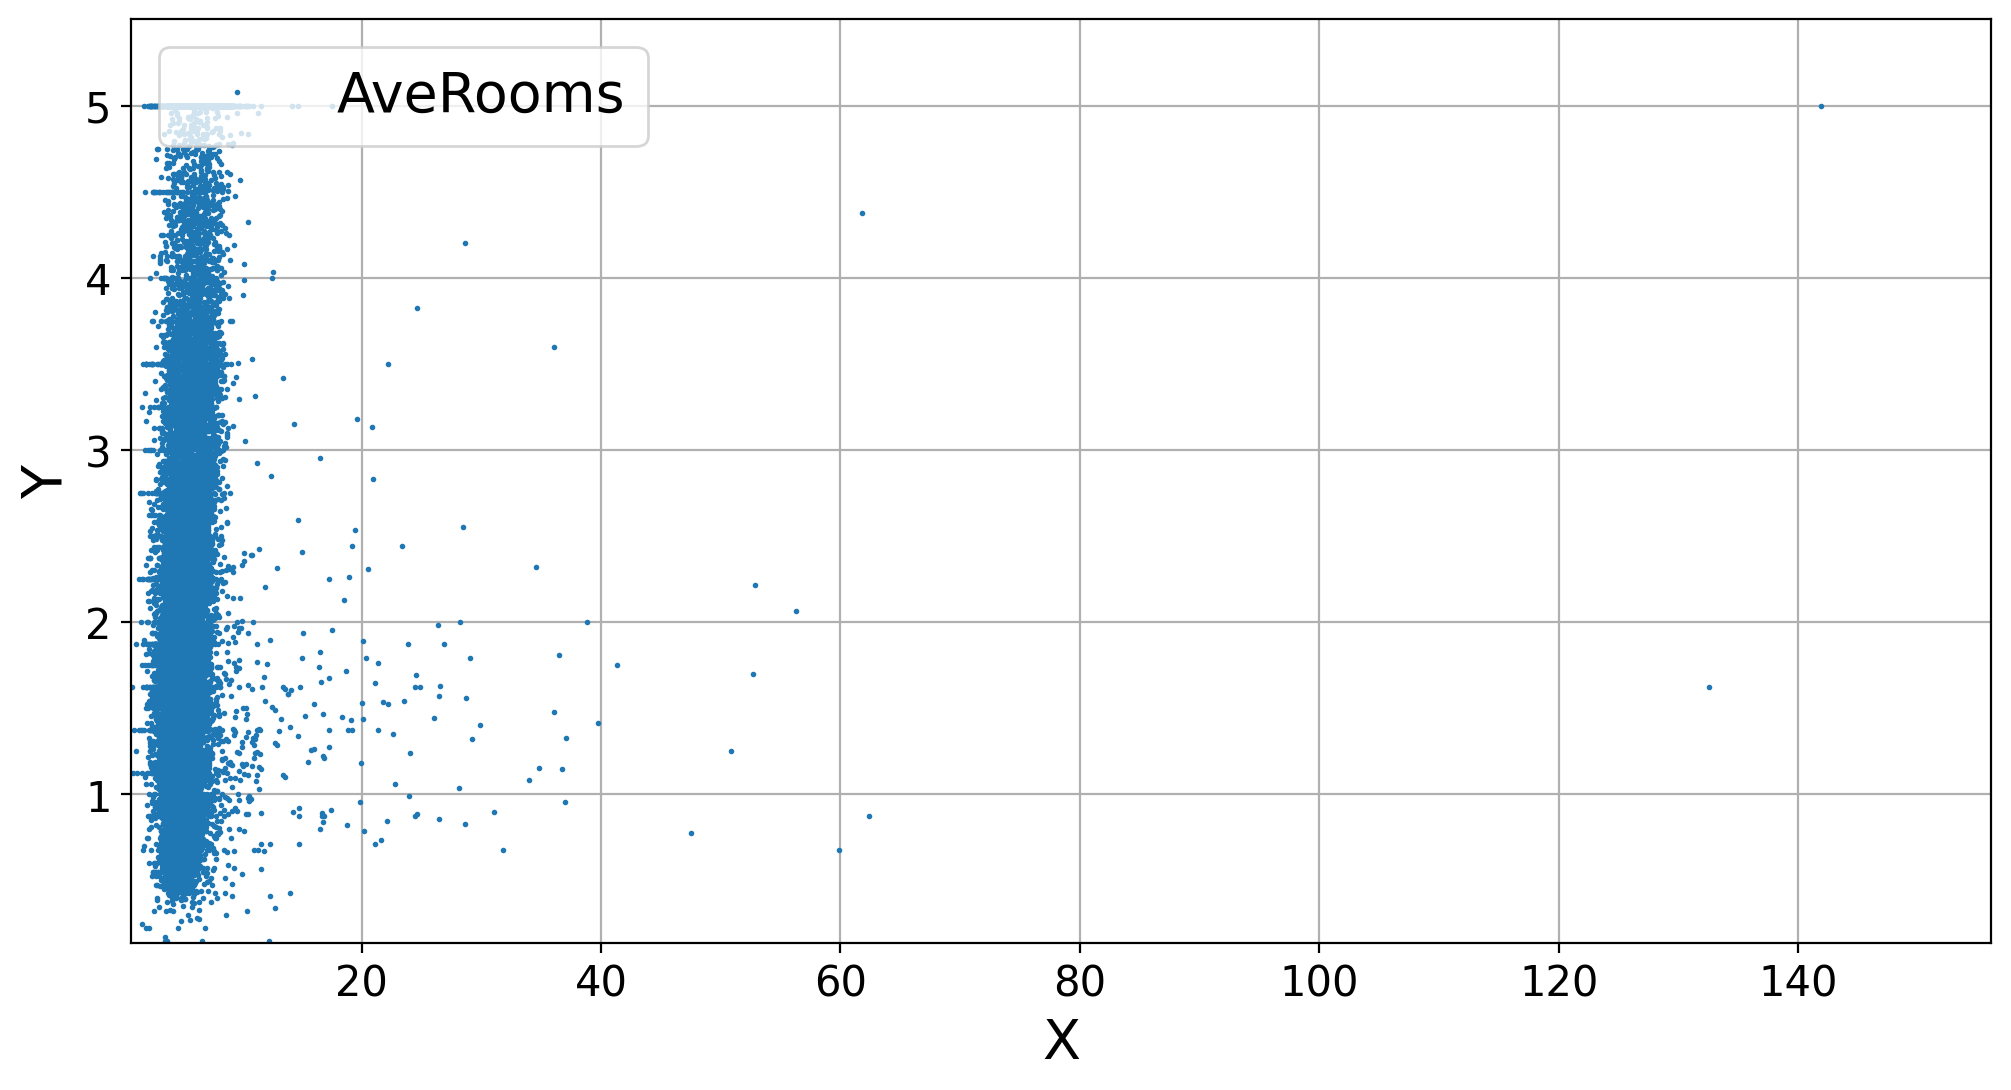

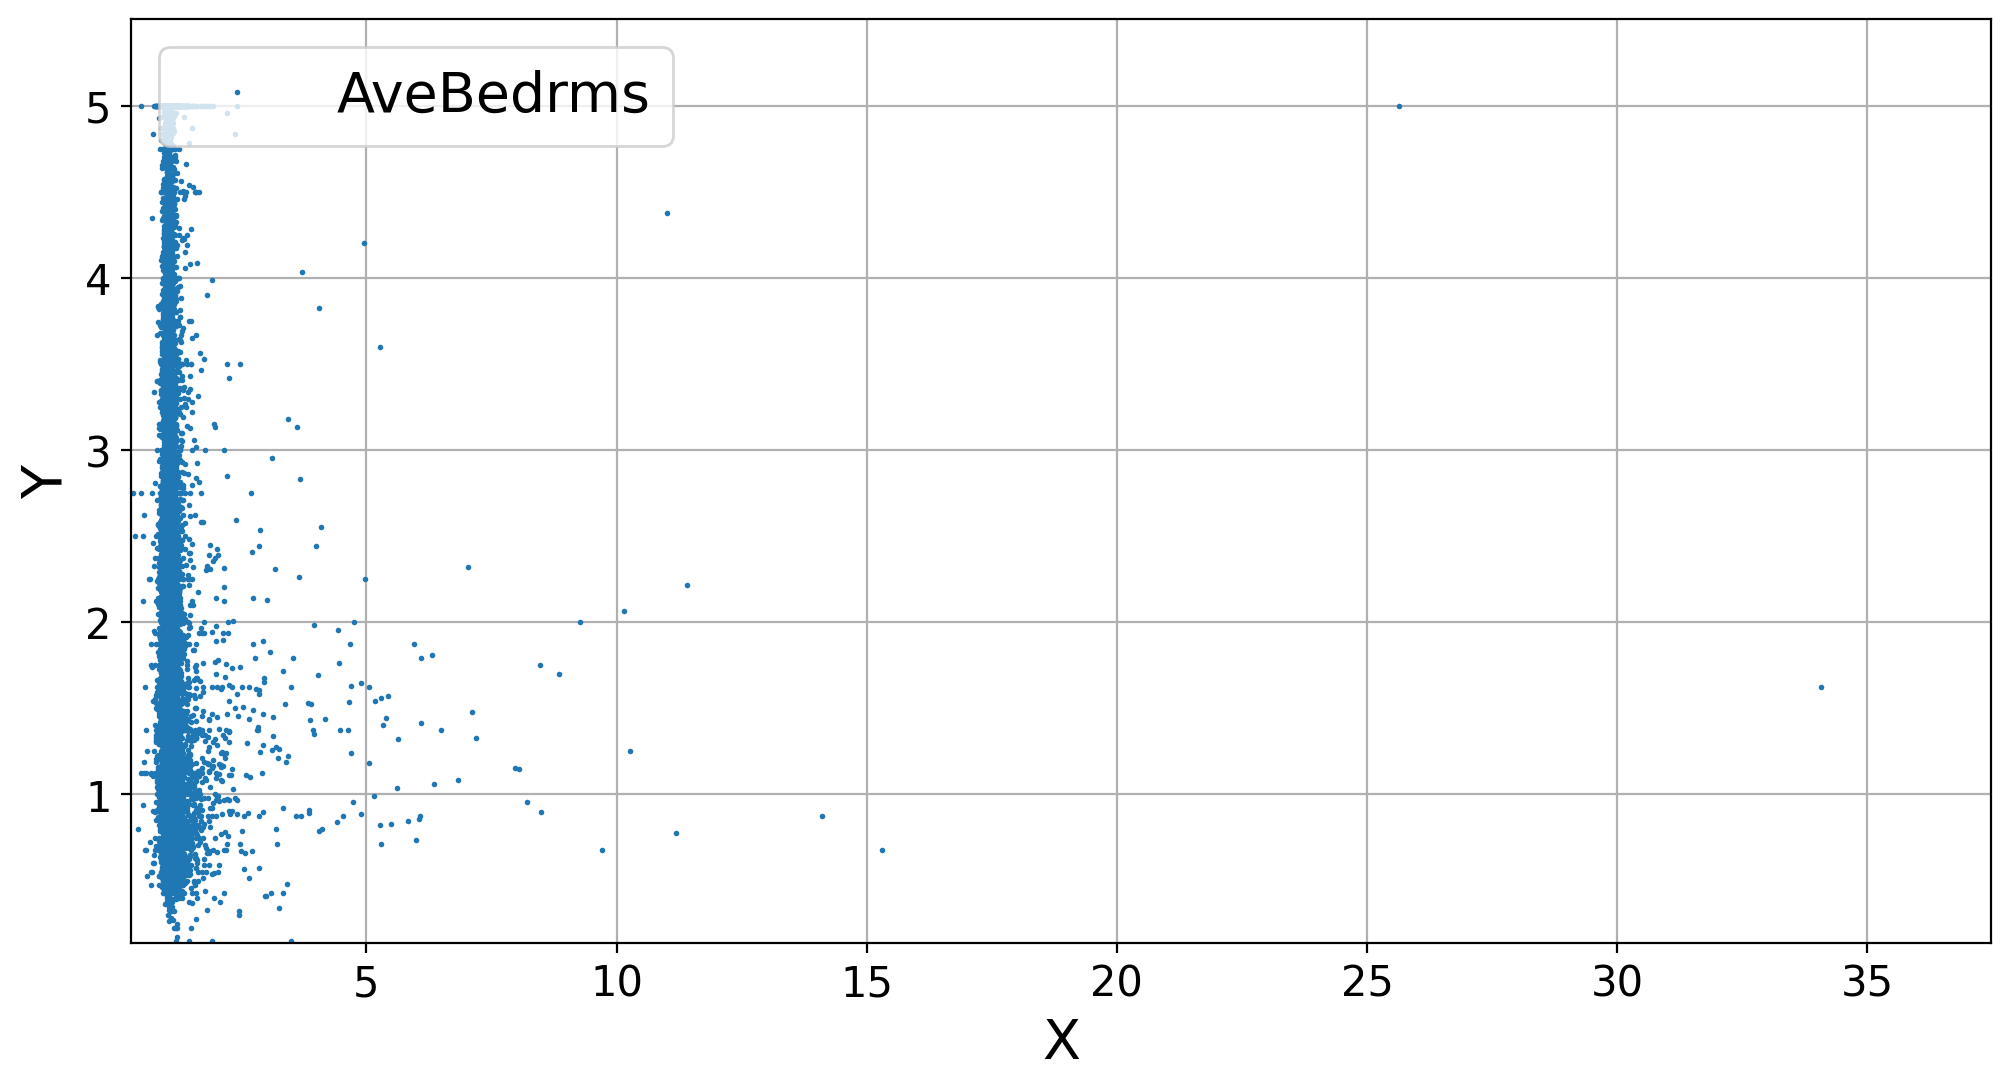

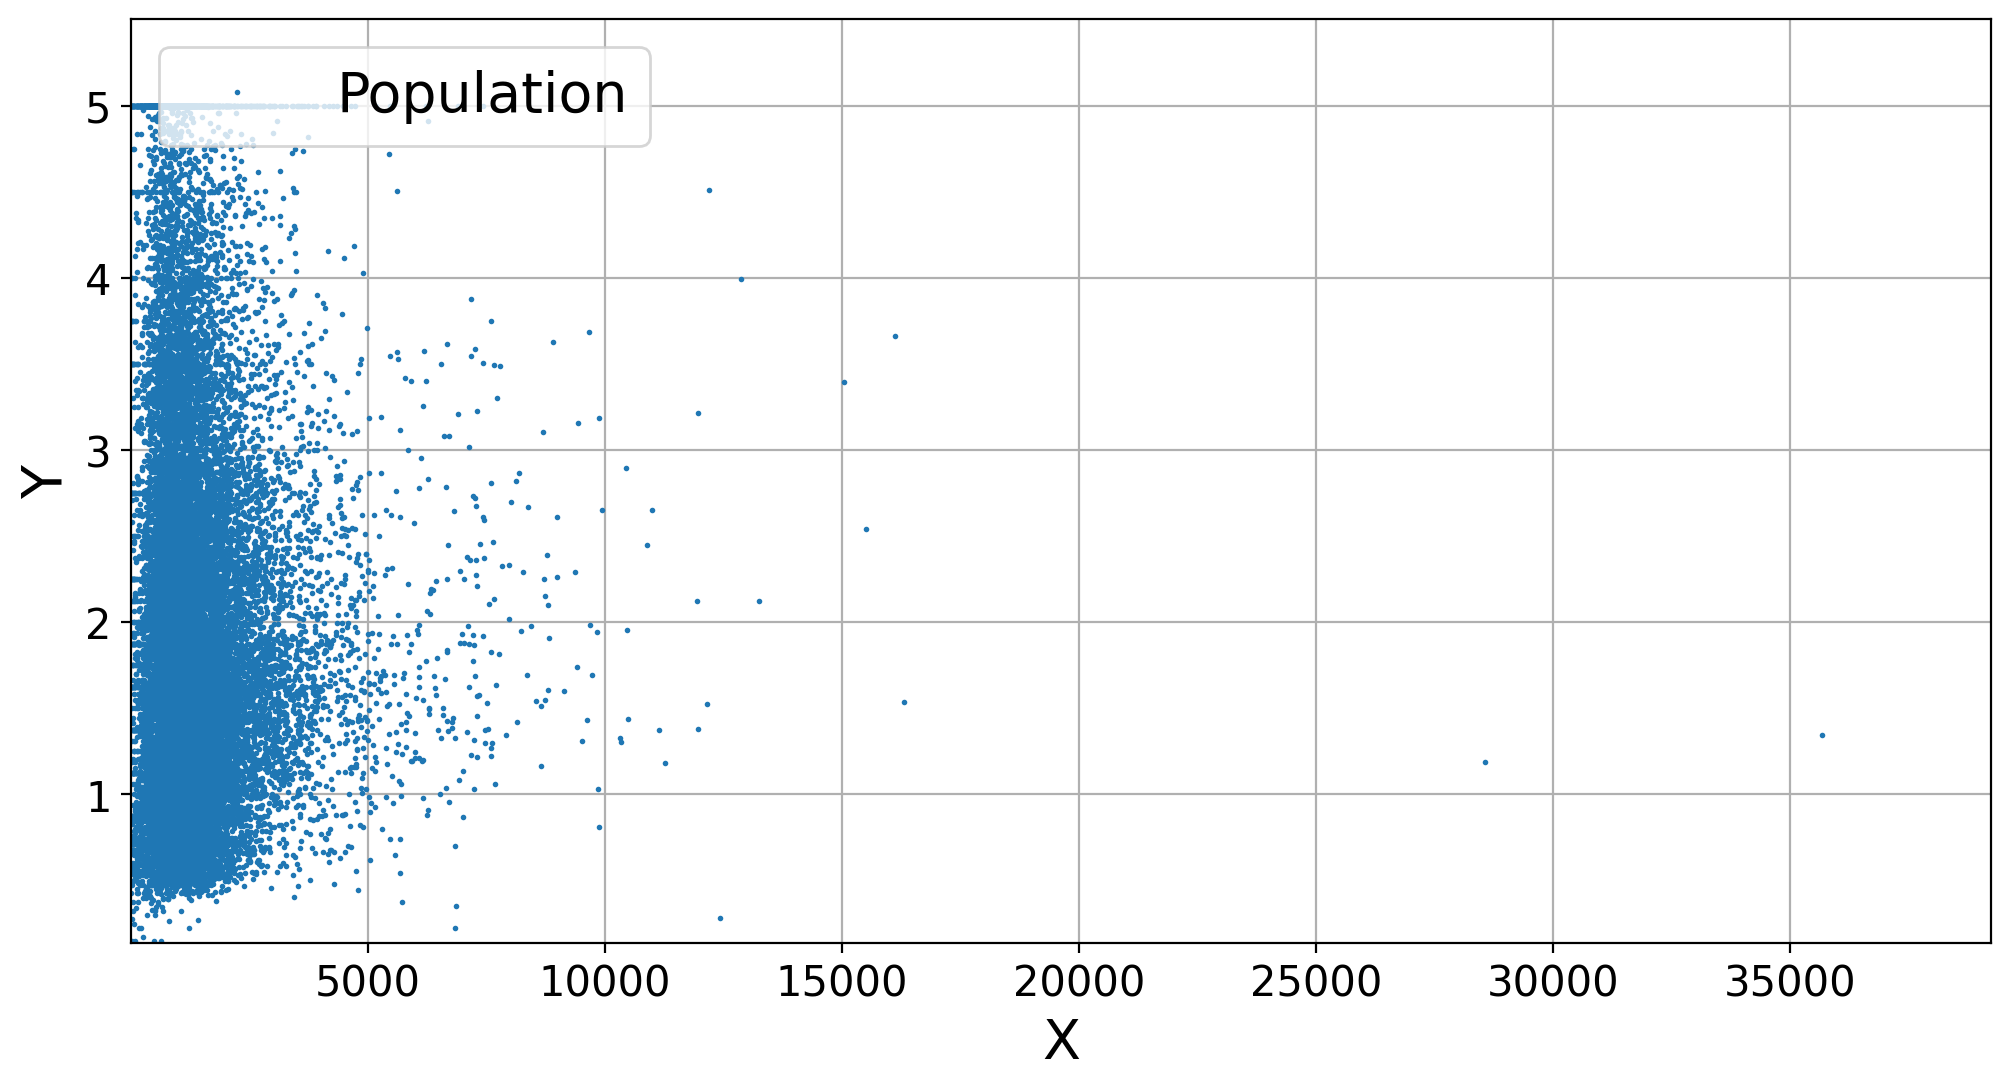

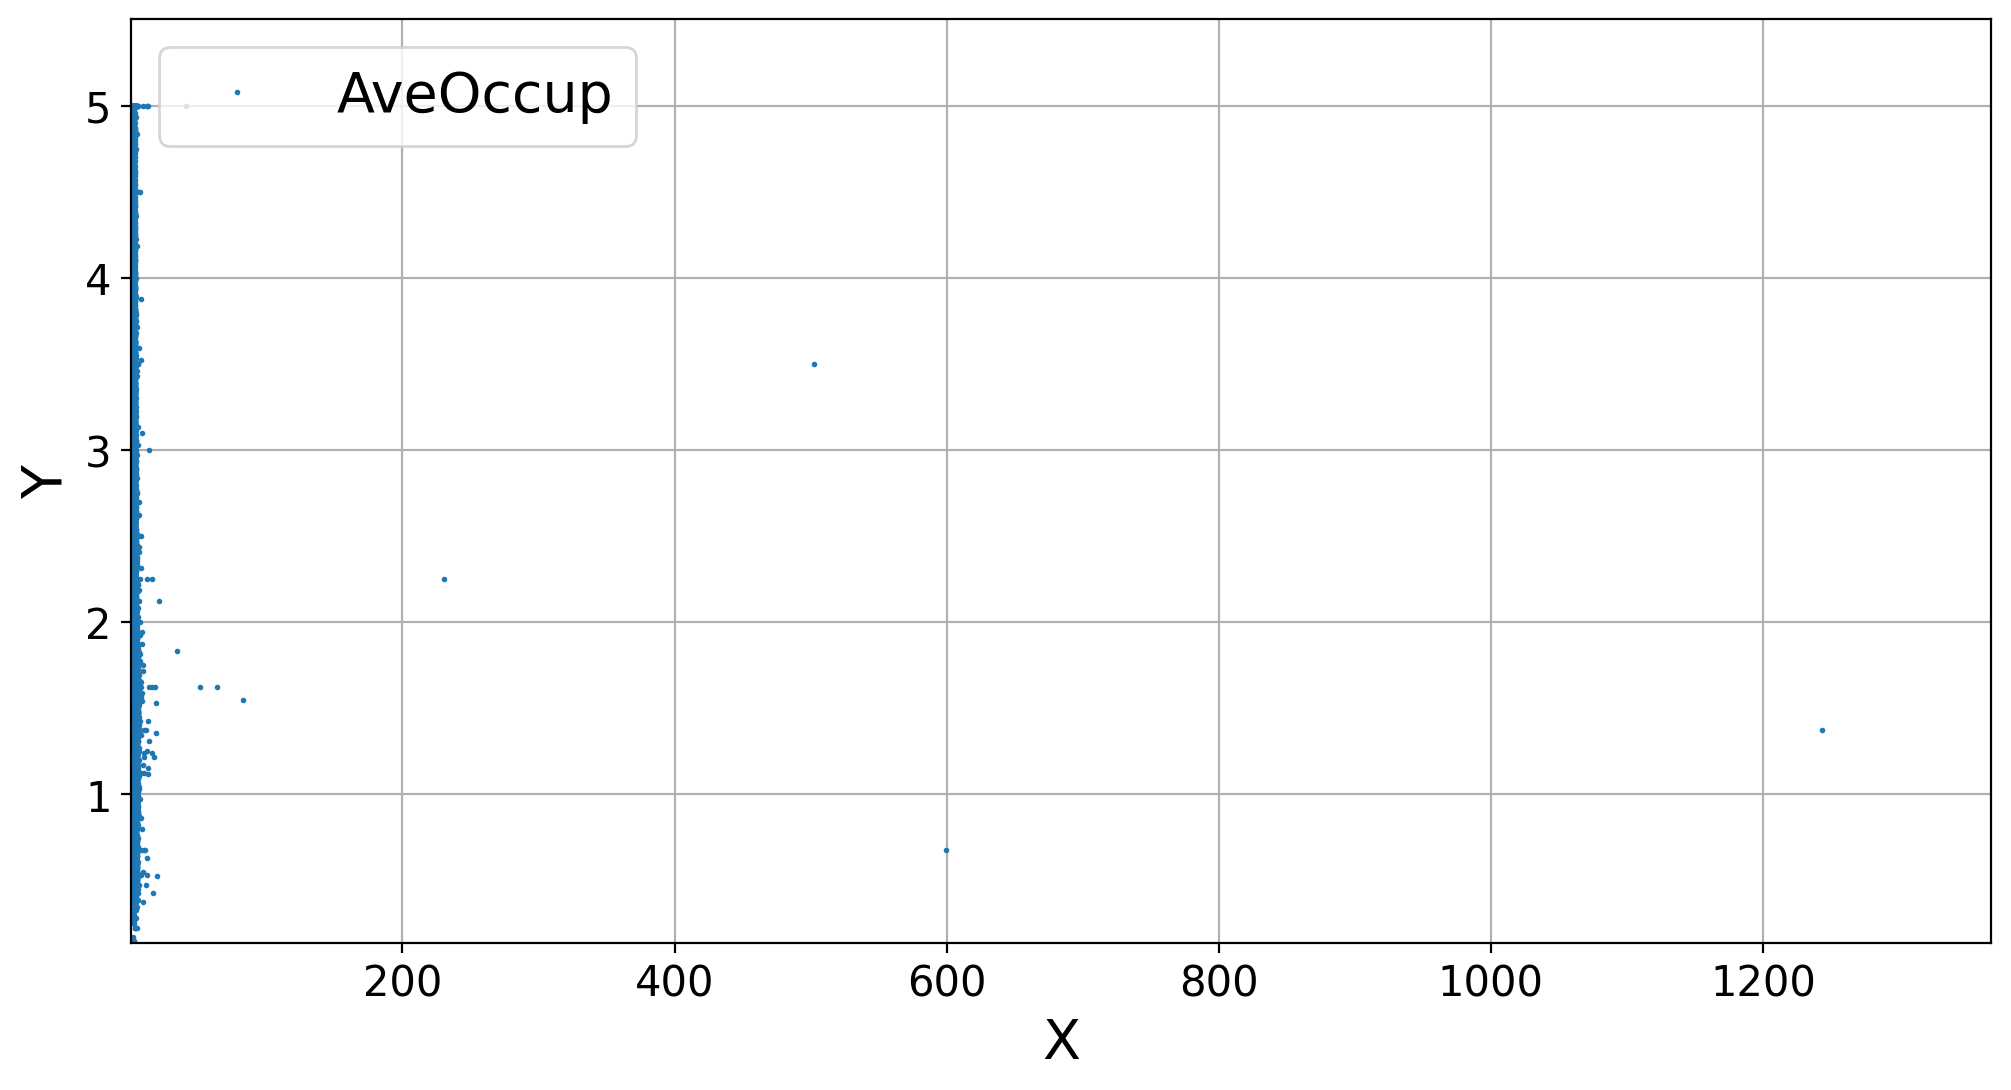

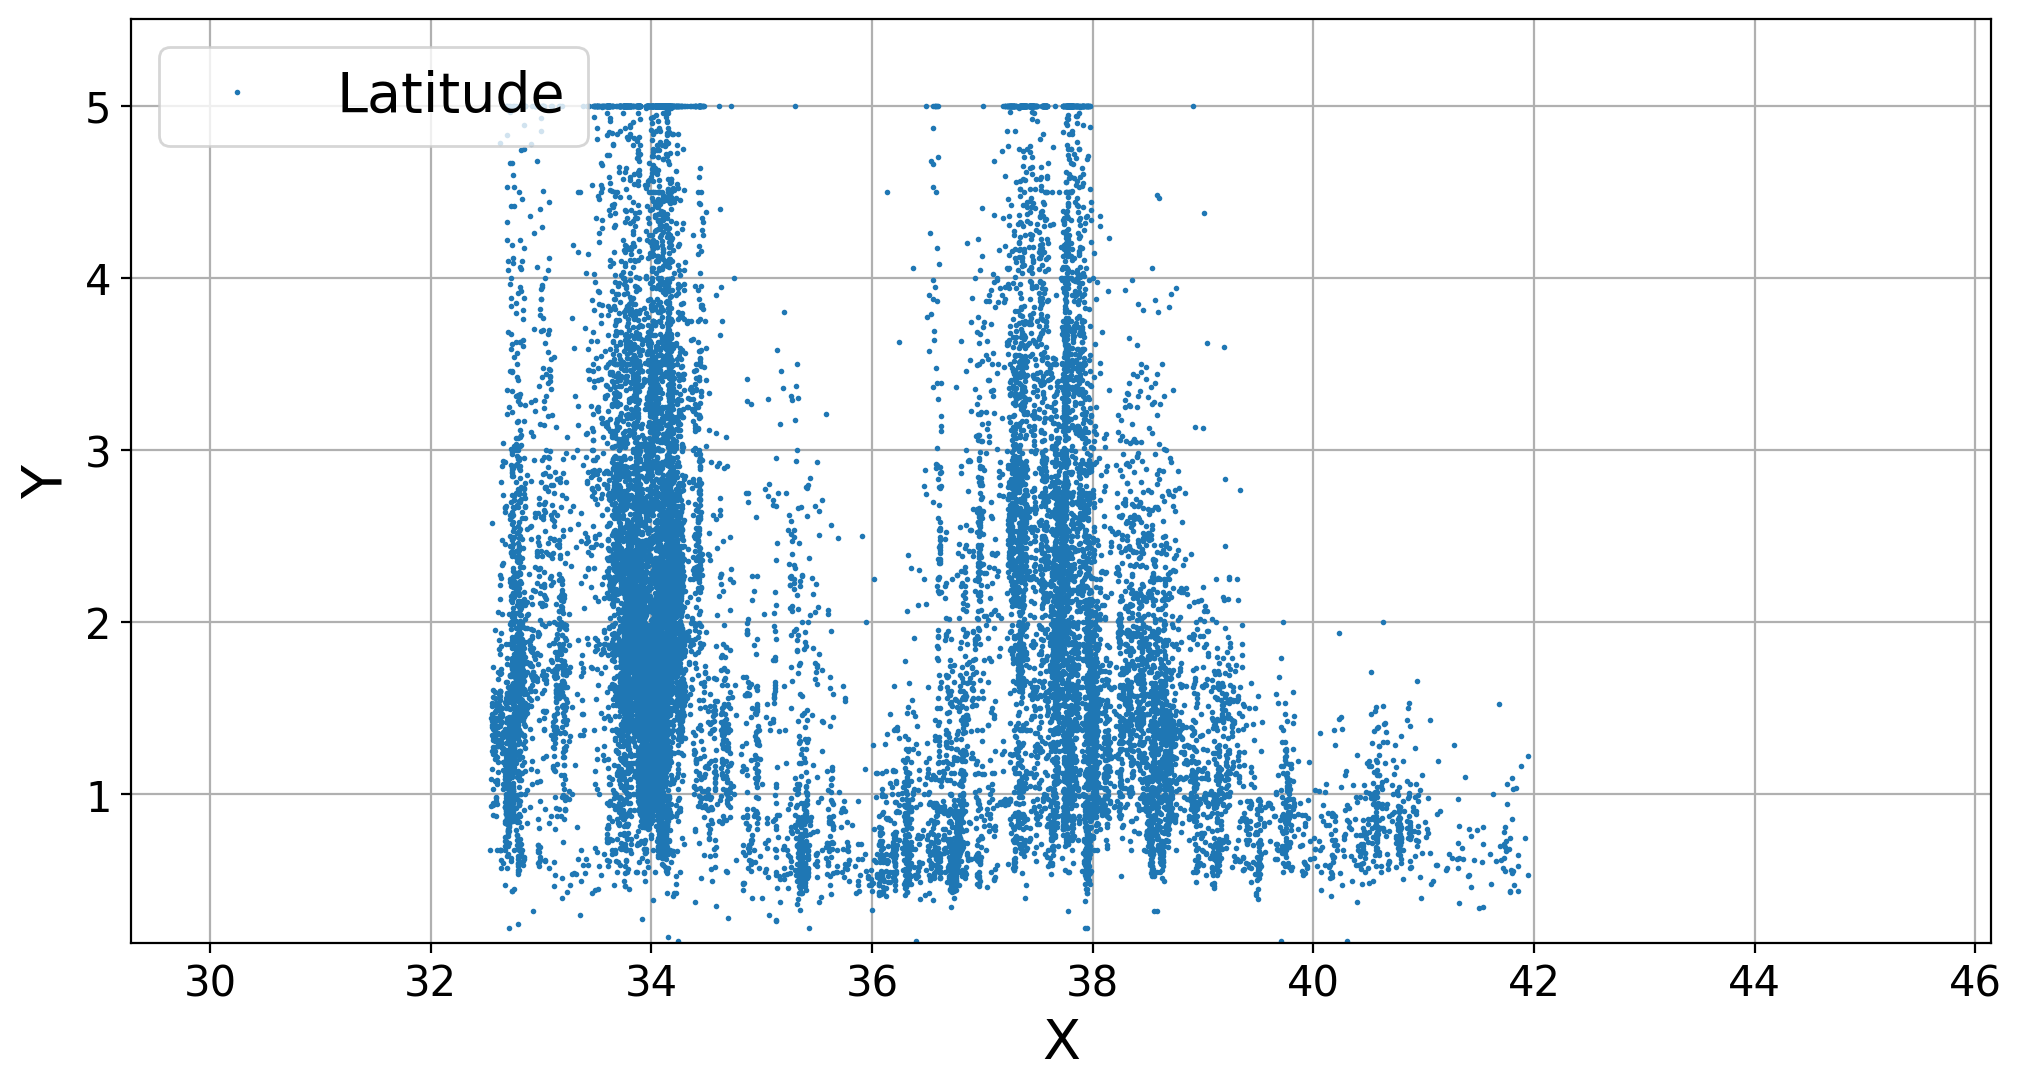

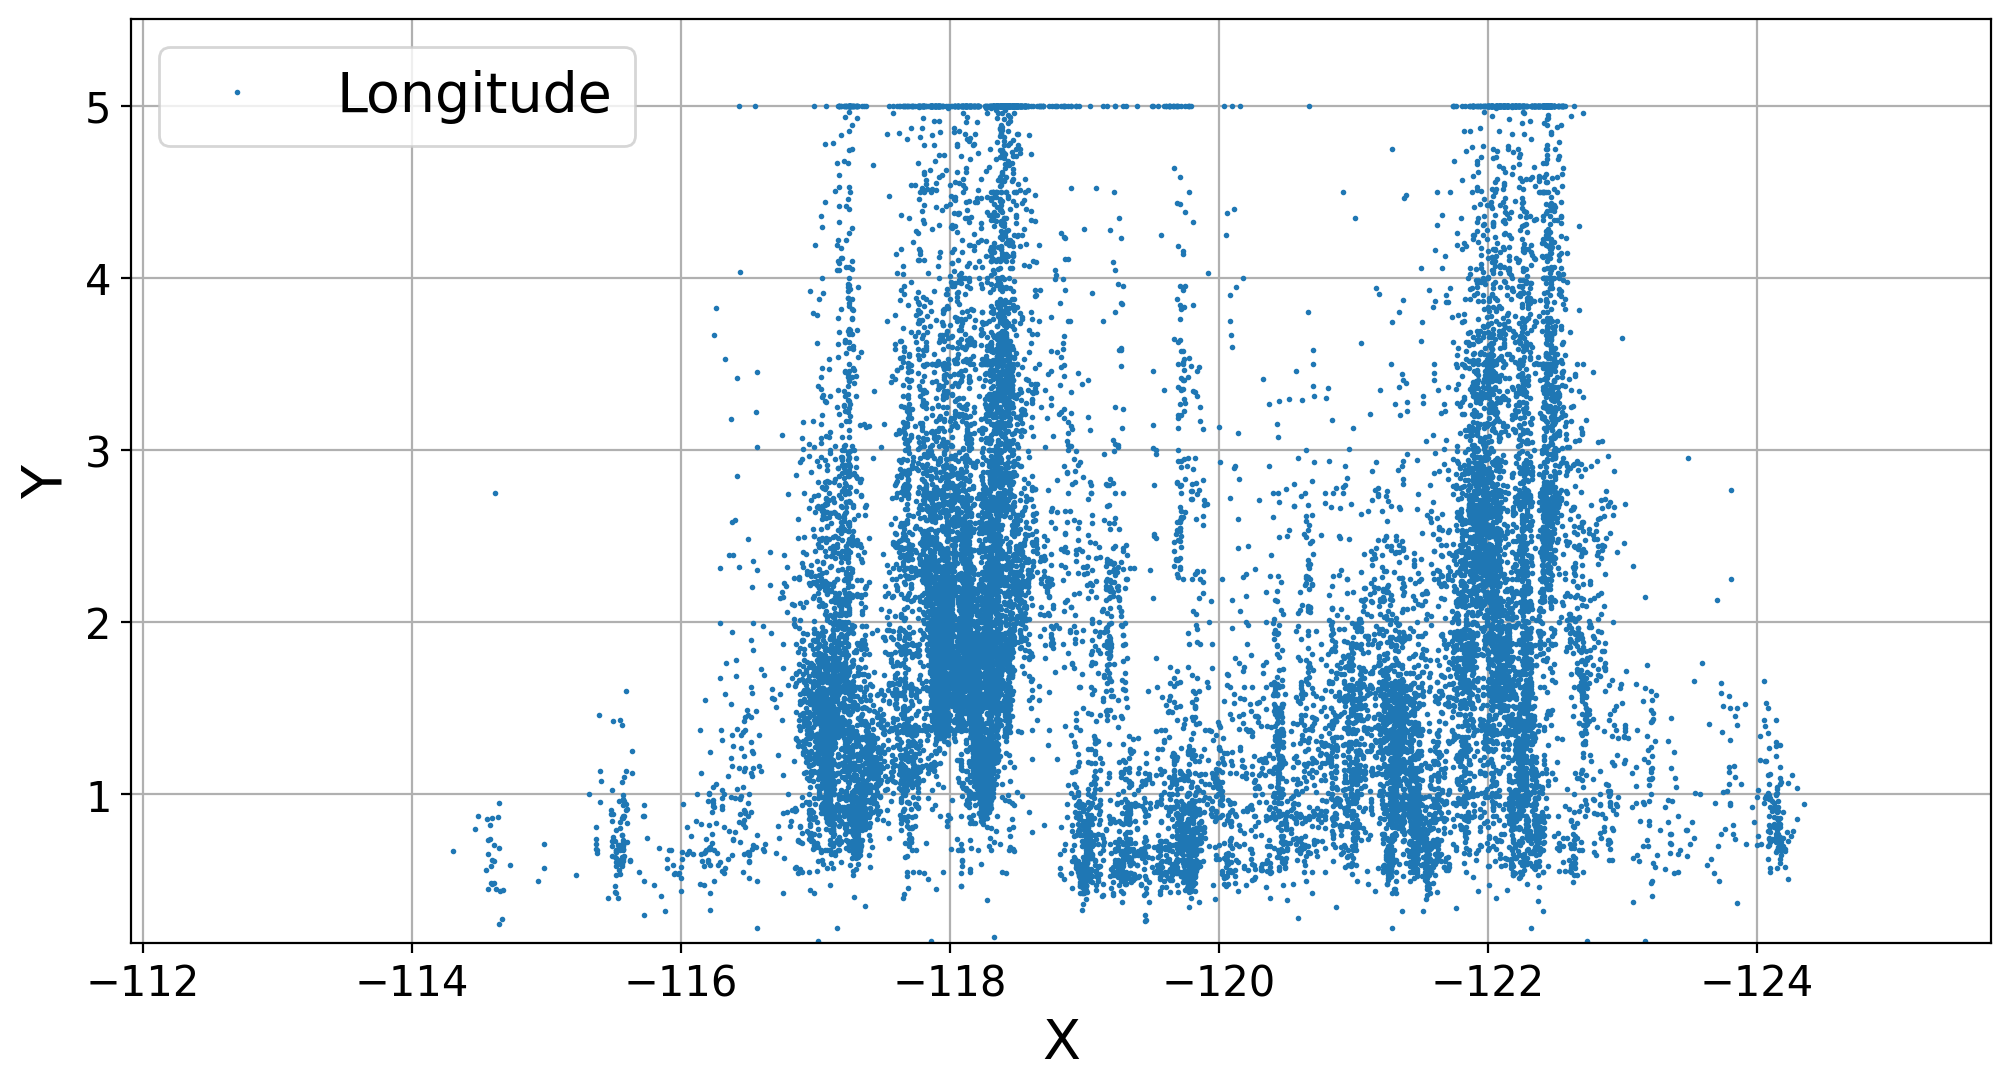

In [ ]:
for index, feature_name in enumerate(housing_data.feature_names):
    plot_res(
        housing_data.data[:, index],
        housing_data.target,
        data_style=[[1, 0]],
        data_labels=[feature_name],
    )

In [ ]:
housing_df = pd.DataFrame(data=housing_data.data, columns=housing_data.feature_names)
housing_df[housing_data.target_names[0]] = housing_data.target

In [ ]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Text(0.5, 0, 'count')

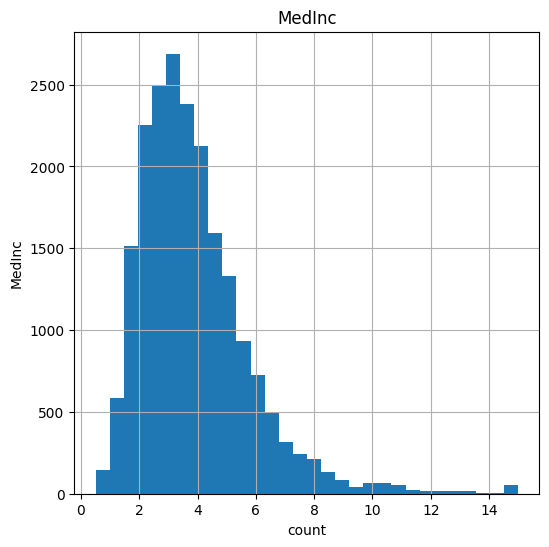

In [ ]:
housing_df[["MedInc"]].hist(figsize=(6, 6), bins=30, grid=True)
plt.ylabel("MedInc")
plt.xlabel("count")

## 4. Datenbereinigung
Die Daten werden auf Ausreißer geprüft und über die IQR-Grenzen bereinigt, damit spätere Analysen stabiler werden.

In [ ]:
iqr_columns = ["AveOccup", "MedInc", "HouseAge"]

q1 = housing_df[iqr_columns].quantile(0.25)
q3 = housing_df[iqr_columns].quantile(0.75)
iqr = q3 - q1

iqr_mask = (
    (housing_df[iqr_columns] >= q1 - 1.5 * iqr)
    & (housing_df[iqr_columns] <= q3 + 1.5 * iqr)
).all(axis=1)

cutoff_mask = (
    (housing_df["MedHouseVal"] < housing_df["MedHouseVal"].max())
    & (housing_df["HouseAge"] < housing_df["HouseAge"].max())
)

clean_df = housing_df[cutoff_mask]
clean_df = clean_df[iqr_mask]
clean_df.describe()

/tmp/ipykernel_605161/3080220170.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[mask_iqr]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000
mean,3.656129,26.994062,5.390943,1.100166,1452.125721,2.877619,35.633647,-119.516388,1.887691
std,1.462256,11.453598,2.345870,0.472148,1099.930009,0.624360,2.162286,1.992080,0.939832
min,0.499900,1.000000,0.846154,0.333333,5.000000,1.169329,32.540000,-124.300000,0.149990
25%,2.546150,17.000000,4.458839,1.006294,807.000000,2.452291,33.930000,-121.600000,1.150250
50%,3.479200,27.000000,5.223624,1.048881,1193.000000,2.827682,34.260000,-118.480000,1.726000
75%,4.600000,36.000000,5.981009,1.099626,1762.000000,3.257576,37.690000,-117.980000,2.427750
max,8.011300,51.000000,132.533333,34.066667,16305.000000,4.560748,41.950000,-114.310000,5.000000


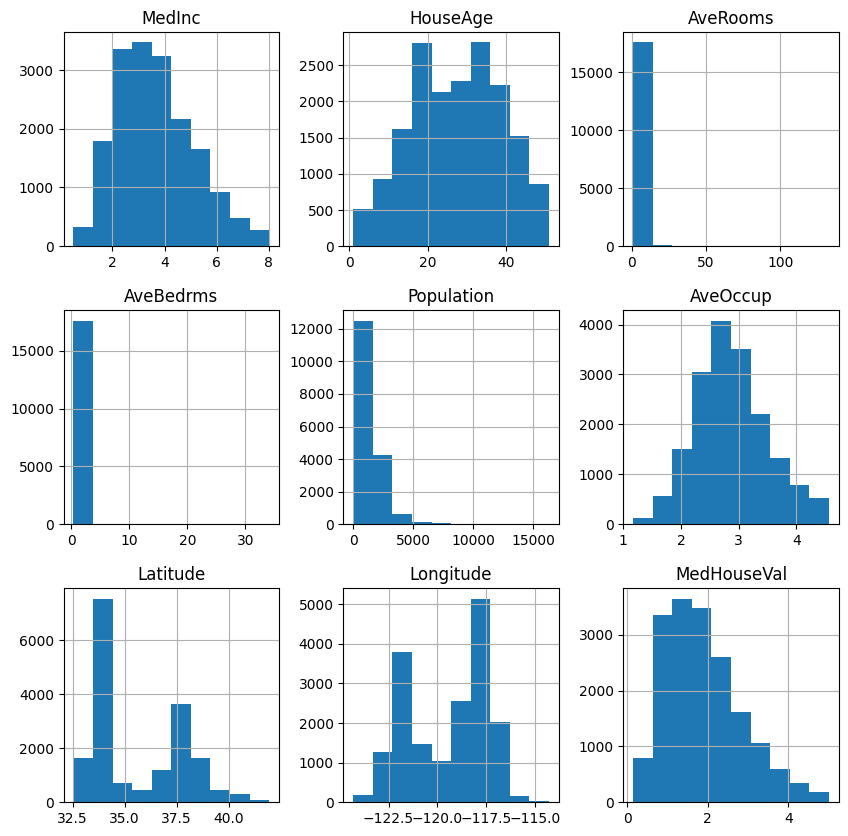

In [ ]:
clean_df.hist(figsize=(10, 10))
plt.savefig("bereinigte_verteilung.pdf", format="pdf")

## 5. Schiefe Verteilungen
Anhand des Skewness-Koeffizienten werden Merkmale mit schiefen Verteilungen identifiziert und log-transformiert.

In [ ]:
skewness_series = clean_df.skew()
high_skew_features = skewness_series[abs(skewness_series) > 1]
high_skew_features

AveRooms      17.062618
AveBedrms     28.924807
Population     3.273234
dtype: float64

In [ ]:
log_transform_columns = ["AveRooms", "AveBedrms", "Population"]
df_log_transformed = clean_df.copy()

for column in log_transform_columns:
    df_log_transformed[column] = np.log1p(clean_df[column])

df_log_transformed.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000,17682.000000
mean,3.656129,26.994062,1.824585,0.733274,7.054398,2.877619,35.633647,-119.516388,1.887691
std,1.462256,11.453598,0.223857,0.108742,0.715278,0.624360,2.162286,1.992080,0.939832
min,0.499900,1.000000,0.613104,0.287682,1.791759,1.169329,32.540000,-124.300000,0.149990
25%,2.546150,17.000000,1.697236,0.696289,6.694562,2.452291,33.930000,-121.600000,1.150250
50%,3.479200,27.000000,1.828352,0.717294,7.085064,2.827682,34.260000,-118.480000,1.726000
75%,4.600000,36.000000,1.943193,0.741759,7.474772,3.257576,37.690000,-117.980000,2.427750
max,8.011300,51.000000,4.894351,3.557251,9.699288,4.560748,41.950000,-114.310000,5.000000


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

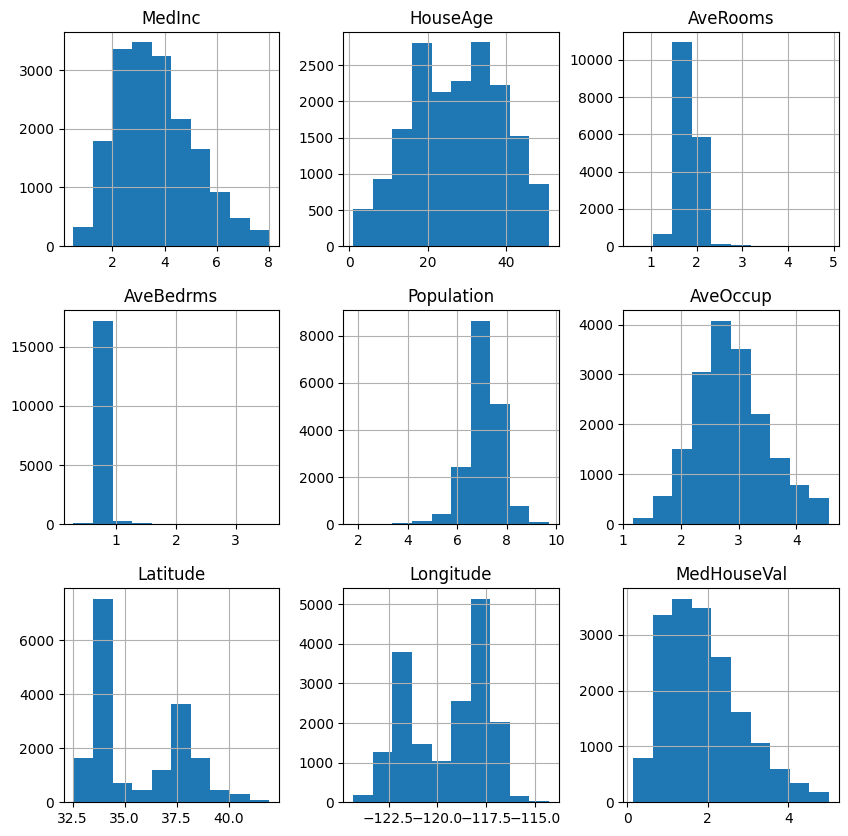

In [ ]:
df_log_transformed.hist(figsize=(10, 10))

## 6. Train/Test-Split & Standardisierung
Die Daten werden in Trainings- und Testdaten aufgeteilt und anschließend standardisiert.

In [ ]:
X = df_log_transformed.drop("MedHouseVal", axis=1)
y = df_log_transformed["MedHouseVal"].copy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.25
)

In [ ]:
standard_scaler = sklearn.preprocessing.StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)